In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

print("Dataset Statistics Analysis Started")

Dataset Statistics Analysis Started


In [2]:
GT_PATH = "../data/train/GT"
NOISY_PATH = "../data/train/NoisyLR"

print("GT Images:", len(os.listdir(GT_PATH)))
print("NoisyLR Images:", len(os.listdir(NOISY_PATH)))

GT Images: 3200
NoisyLR Images: 3200


In [3]:
gt_shapes = []
noisy_shapes = []

files = sorted(os.listdir(GT_PATH))

for f in tqdm(files):

    gt = np.load(os.path.join(GT_PATH,f))
    noisy = np.load(os.path.join(NOISY_PATH,f))

    gt_shapes.append(gt.shape)
    noisy_shapes.append(noisy.shape)


print("Unique GT shapes:")
print(set(gt_shapes))


print("\nUnique NoisyLR shapes:")
print(set(noisy_shapes))

100%|██████████| 3200/3200 [00:38<00:00, 83.55it/s] 

Unique GT shapes:
{(256, 256)}

Unique NoisyLR shapes:
{(128, 128)}


In [4]:
gt_mean=[]
gt_std=[]

noisy_mean=[]
noisy_std=[]


for f in tqdm(files):

    gt=np.load(os.path.join(GT_PATH,f))
    noisy=np.load(os.path.join(NOISY_PATH,f))


    gt_mean.append(gt.mean())
    gt_std.append(gt.std())

    noisy_mean.append(noisy.mean())
    noisy_std.append(noisy.std())


print("GT Mean intensity")
print(np.mean(gt_mean))


print("\nGT Std")
print(np.mean(gt_std))


print("\nNoisyLR Mean intensity")
print(np.mean(noisy_mean))


print("\nNoisyLR Std")
print(np.mean(noisy_std))

100%|██████████| 3200/3200 [00:01<00:00, 2002.70it/s]

GT Mean intensity
0.43352845

GT Std
0.18762915

NoisyLR Mean intensity
0.4335363

NoisyLR Std
0.20579524


In [5]:
gt_min=[]
gt_max=[]

noisy_min=[]
noisy_max=[]


for f in tqdm(files):

    gt=np.load(os.path.join(GT_PATH,f))
    noisy=np.load(os.path.join(NOISY_PATH,f))


    gt_min.append(gt.min())
    gt_max.append(gt.max())

    noisy_min.append(noisy.min())
    noisy_max.append(noisy.max())


print("GT range")
print(min(gt_min), max(gt_max))


print("\nNoisyLR range")
print(min(noisy_min), max(noisy_max))

100%|██████████| 3200/3200 [00:01<00:00, 2979.63it/s]

GT range
0.0 1.0

NoisyLR range
-0.27856305 2.158005


In [6]:
from skimage.transform import resize


noise_values=[]


for f in tqdm(files):

    gt=np.load(os.path.join(GT_PATH,f))
    noisy=np.load(os.path.join(NOISY_PATH,f))


    noisy_up = resize(
        noisy,
        gt.shape,
        anti_aliasing=True
    )


    error = np.abs(gt-noisy_up)

    noise_values.append(error.mean())


print(
    "Average degradation error:",
    np.mean(noise_values)
)

100%|██████████| 3200/3200 [00:07<00:00, 420.66it/s]

Average degradation error: 0.04730437


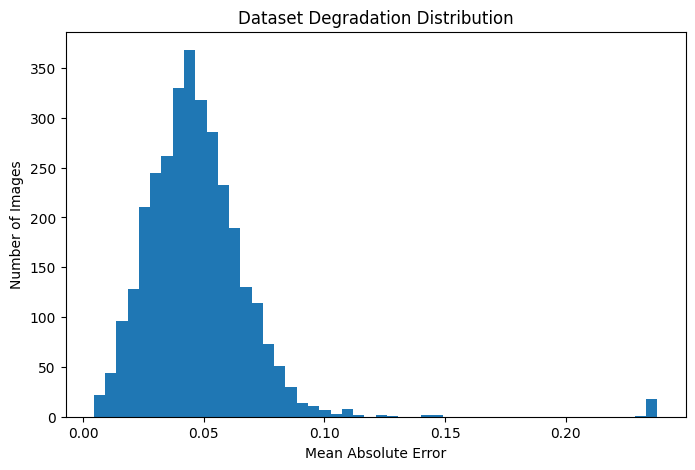

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    noise_values,
    bins=50
)

plt.xlabel("Mean Absolute Error")
plt.ylabel("Number of Images")
plt.title("Dataset Degradation Distribution")

plt.show()